# Neural Network Classifier

This notebook implements a small fully connected neural network in
PyTorch for Higgs signal/background classification.

The goal is to understand the basic neural-network training workflow:

- preprocessing;
- tensors and batches;
- forward propagation;
- loss calculation;
- backpropagation;
- optimization;
- validation;
- early stopping.

The independent test sample is kept untouched and is evaluated only in
`03_final_evaluation.ipynb`.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


print(sys.executable)
print("PyTorch:", torch.__version__)
print("Device:", "CUDA" if torch.cuda.is_available() else "CPU")

/home/kethe/AI_projects/higgs_ml/.venv/bin/python
PyTorch: 2.14.0+cpu
Device: CPU


## 2. Define features and target

We exclude `EventId`, `Weight`, and `Label` from the neural-network inputs.

The target is encoded as:

- `0` = background
- `1` = signal

In [2]:
df = pd.read_csv("../data/training.csv")

feature_columns = [
    column
    for column in df.columns
    if column not in ["EventId", "Weight", "Label"]
]

X = df[feature_columns].replace(-999, np.nan)
y = (df["Label"] == "s").astype(int)

## 3. Create training, validation and test samples

The final test sample is kept separate from neural-network training.

The development sample is further divided into training and validation
samples for monitoring the model during training.

In [3]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.2,
    random_state=42,
    stratify=y_dev,
)

## 4. Preprocessing

Missing values are imputed using statistics learned from the training
sample.

The input features are then standardized.

Validation and test data are transformed using the parameters learned
from the training data only.

In [4]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

In [5]:
X_train_processed = imputer.fit_transform(X_train)
X_val_processed = imputer.transform(X_val)
X_test_processed = imputer.transform(X_test)

In [6]:
X_train_processed = scaler.fit_transform(X_train_processed)
X_val_processed = scaler.transform(X_val_processed)
X_test_processed = scaler.transform(X_test_processed)

## 5. Convert data to PyTorch tensors

PyTorch models operate on tensors rather than pandas DataFrames.

In [7]:
X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

X_val_tensor = torch.tensor(
    X_val_processed,
    dtype=torch.float32,
)

y_val_tensor = torch.tensor(
    y_val.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32,
)

y_test_tensor = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

X_train_tensor.shape, y_train_tensor.shape

(torch.Size([160000, 30]), torch.Size([160000, 1]))

## 6. Define the neural-network architecture

The network contains two hidden layers:

```text
30 input features
       ↓
64 neurons
       ↓
ReLU
       ↓
32 neurons
       ↓
ReLU
       ↓
1 output logit

In [8]:
class HiggsNetwork(nn.Module):

    def __init__(self, n_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)

In [9]:
model = HiggsNetwork(
    n_features=X_train_tensor.shape[1]
)

model

HiggsNetwork(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

## 7. Loss function and optimizer

Binary cross-entropy with logits is used as the classification loss.

The Adam optimizer updates the neural-network parameters using the
gradients obtained through backpropagation.

In [10]:
loss_function = nn.BCEWithLogitsLoss()

In [11]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
)

## 8. Mini-batch training

In [12]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
)

## 9. Training loop

For each mini-batch:

1. perform a forward pass;
2. calculate the loss;
3. compute gradients using backpropagation;
4. update the model parameters.

In [13]:
def train_one_epoch(model, loader, optimizer, loss_function):

    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = loss_function(
            logits,
            y_batch,
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * len(X_batch)

    return total_loss / len(loader.dataset)

In [15]:
def predict_probability(model, X):

    model.eval()

    with torch.no_grad():
        logits = model(X)
        probabilities = torch.sigmoid(logits)

    return probabilities.numpy().ravel()

def evaluate_auc(model, X, y):

    probabilities = predict_probability(model, X)

    return roc_auc_score(
        y,
        probabilities,
    )

In [16]:
loss_history = []
train_auc_history = []
val_auc_history = []

best_val_auc = -np.inf
best_state = None

patience = 3
epochs_without_improvement = 0
max_epochs = 30

for epoch in range(max_epochs):

    loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        loss_function,
    )

    train_auc = evaluate_auc(
        model,
        X_train_tensor,
        y_train,
    )

    val_auc = evaluate_auc(
        model,
        X_val_tensor,
        y_val,
    )

    loss_history.append(loss)
    train_auc_history.append(train_auc)
    val_auc_history.append(val_auc)

    print(
        f"Epoch {epoch + 1:2d} | "
        f"Loss = {loss:.4f} | "
        f"Train AUC = {train_auc:.4f} | "
        f"Val AUC = {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {
            key: value.detach().clone()
            for key, value in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping.")
            break

Epoch  1 | Loss = 0.5042 | Train AUC = 0.8782 | Val AUC = 0.8776
Epoch  2 | Loss = 0.3978 | Train AUC = 0.8937 | Val AUC = 0.8935
Epoch  3 | Loss = 0.3833 | Train AUC = 0.8983 | Val AUC = 0.8979
Epoch  4 | Loss = 0.3771 | Train AUC = 0.9012 | Val AUC = 0.9002
Epoch  5 | Loss = 0.3722 | Train AUC = 0.9031 | Val AUC = 0.9016
Epoch  6 | Loss = 0.3691 | Train AUC = 0.9051 | Val AUC = 0.9027
Epoch  7 | Loss = 0.3665 | Train AUC = 0.9061 | Val AUC = 0.9035
Epoch  8 | Loss = 0.3642 | Train AUC = 0.9070 | Val AUC = 0.9043
Epoch  9 | Loss = 0.3626 | Train AUC = 0.9080 | Val AUC = 0.9051
Epoch 10 | Loss = 0.3612 | Train AUC = 0.9086 | Val AUC = 0.9055
Epoch 11 | Loss = 0.3598 | Train AUC = 0.9095 | Val AUC = 0.9060
Epoch 12 | Loss = 0.3584 | Train AUC = 0.9096 | Val AUC = 0.9062
Epoch 13 | Loss = 0.3574 | Train AUC = 0.9096 | Val AUC = 0.9058
Epoch 14 | Loss = 0.3565 | Train AUC = 0.9108 | Val AUC = 0.9071
Epoch 15 | Loss = 0.3559 | Train AUC = 0.9110 | Val AUC = 0.9070
Epoch 16 | Loss = 0.3550 

In [17]:
model.load_state_dict(best_state)

print(
    f"Best validation ROC-AUC: {best_val_auc:.4f}"
)

Best validation ROC-AUC: 0.9087


## 10. Training loss

The training loss should generally decrease as the network learns.

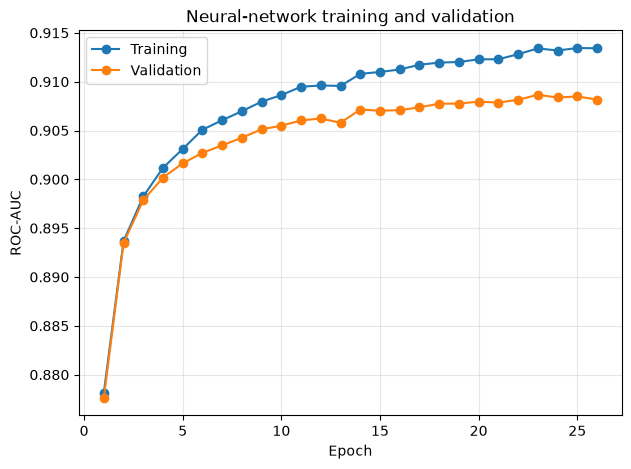

In [18]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, len(train_auc_history) + 1),
    train_auc_history,
    marker="o",
    label="Training",
)

plt.plot(
    range(1, len(val_auc_history) + 1),
    val_auc_history,
    marker="o",
    label="Validation",
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Neural-network training and validation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 11. Validation performance

In [19]:
def predict_probability(model, X):

    model.eval()

    with torch.no_grad():
        logits = model(X)
        probabilities = torch.sigmoid(logits)

    return probabilities.numpy().ravel()

In [20]:
nn_val_score = predict_probability(
    model,
    X_val_tensor,
)

In [21]:
nn_val_auc = roc_auc_score(
    y_val,
    nn_val_score,
)

print(f"Neural network validation AUC: {nn_val_auc:.4f}")

Neural network validation AUC: 0.9087


## 12. Comparison with classical ML models

For context, we train the logistic-regression baseline and
gradient-boosted-tree model on the same development sample and compare
their validation ROC-AUC with the neural network.

In [22]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000)),
])

logistic_model.fit(X_train, y_train)
logistic_val_score = logistic_model.predict_proba(X_val)[:, 1]
logistic_val_auc = roc_auc_score(
    y_val,
    logistic_val_score,
)

print(f"Logistic regression validation AUC: {logistic_val_auc:.4f}")

Logistic regression validation AUC: 0.8166


In [23]:
final_tree = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42,
)

final_tree.fit(X_train, y_train)
tree_val_score = final_tree.predict_proba(X_val)[:, 1]
tree_val_auc = roc_auc_score(
    y_val,
    tree_val_score,
)

print(f"Boosted-tree validation AUC: {tree_val_auc:.4f}")

Boosted-tree validation AUC: 0.9102


In [24]:
results = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "Boosted trees",
        "Neural network",
    ],
    "Validation ROC-AUC": [
        logistic_val_auc,
        tree_val_auc,
        nn_val_auc,
    ],
})

results

,Model,Validation ROC-AUC
0,Logistic regression,0.816616
1,Boosted trees,0.910242
2,Neural network,0.908664


In [25]:
nn_fpr, nn_tpr, _ = roc_curve(
    y_val,
    nn_val_score,
)

tree_fpr, tree_tpr, _ = roc_curve(
    y_val,
    tree_val_score,
)

log_fpr, log_tpr, _ = roc_curve(
    y_val,
    logistic_val_score,
)

## 13. Validation ROC curves

The ROC curves provide a threshold-independent comparison of the three
classifiers.

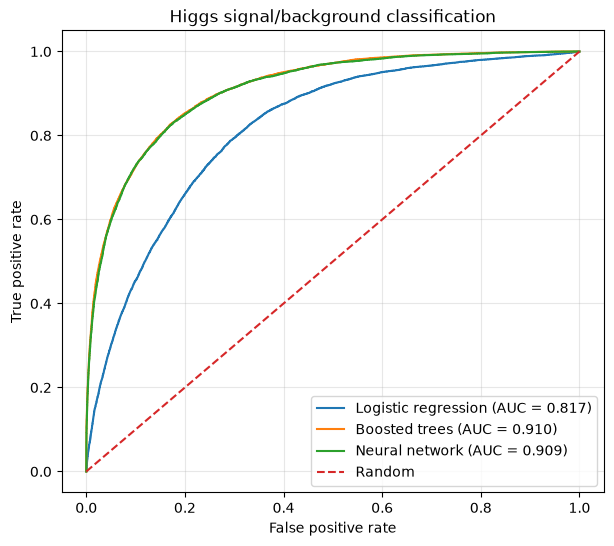

In [26]:
plt.figure(figsize=(7, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic regression (AUC = {logistic_val_auc:.3f})",
)

plt.plot(
    tree_fpr,
    tree_tpr,
    label=f"Boosted trees (AUC = {tree_val_auc:.3f})",
)

plt.plot(
    nn_fpr,
    nn_tpr,
    label=f"Neural network (AUC = {nn_val_auc:.3f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random",
)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Higgs signal/background classification")
plt.legend()
plt.grid(alpha=0.3)

plt.show()